# Using SEED Dataset for creating **EEG** **model**



In [ ]:
# Cell 1: Environment Setup and Library Imports

import os
import glob
import math
import kagglehub
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Initialize Kaggle dataset download for SEED-IV
print("Initializing SEED-IV dataset acquisition...")
path = kagglehub.dataset_download("phhasian0710/seed-iv")
data_dir = os.path.join(path, 'eeg_feature_smooth')
print(f"Data directory verified at: {data_dir}")

Initializing SEED-IV dataset acquisition...
Using Colab cache for faster access to the 'seed-iv' dataset.
Data directory verified at: /kaggle/input/seed-iv/eeg_feature_smooth


In [ ]:
# Cell 2: Data Engineering and Preprocessing

class SEED4Dataset(Dataset):
    # Custom Dataset class for SEED-IV.
    # Implements channel reduction, session-specific label mapping,
    # and multi-subject Z-Score normalisation.
    def __init__(self, data_dir):
        # Label configuration: 0: Neutral, 1: Sad, 2: Fear, 3: Happy
        self.labels_map = {
            1: [1,2,3,0,2,0,0,1,0,1,2,1,1,1,2,3,2,2,3,3,0,3,0,3],
            2: [2,1,3,0,0,2,0,2,3,3,2,3,2,0,1,1,2,1,0,3,0,1,3,1],
            3: [1,2,2,1,3,3,3,1,1,2,1,0,2,3,3,0,2,3,0,0,2,0,1,0]
        }

        # Standard 8-channel OpenBCI Electrode Mapping (F3, F4, T7, T8, P3, P4, O1, O2)
        self.openbci_indices = [7, 11, 14, 22, 47, 51, 54, 58]

        self.data = []
        self.labels = []

        print("Parsing MAT files and synchronizing session-specific metadata...")
        mat_files = glob.glob(os.path.join(data_dir, '**', '*.mat'), recursive=True)

        for file_path in mat_files:
            # Determine Session ID via parent directory naming convention
            parent_folder = os.path.basename(os.path.dirname(file_path))
            try:
                session_id = int(parent_folder)
            except ValueError:
                continue

            if session_id not in self.labels_map:
                continue

            mat_data = sio.loadmat(file_path)

            for trial in range(1, 25):
                key = f'de_movingAve{trial}'
                if key in mat_data:
                    # Isolate target channels and temporal frames
                    trial_data = mat_data[key][self.openbci_indices, :, :]

                    num_frames = trial_data.shape[1]
                    for frame in range(num_frames):
                        self.data.append(trial_data[:, frame, :])
                        self.labels.append(self.labels_map[session_id][trial - 1])

        self.data = np.array(self.data, dtype=np.float32)
        self.labels = np.array(self.labels, dtype=np.int64)

        # Execute Z-Score Normalization to stabilize cross-subject variances
        # Formula: (x - mean) / std
        mean = np.mean(self.data, axis=0, keepdims=True)
        std = np.std(self.data, axis=0, keepdims=True)
        self.data = (self.data - mean) / (std + 1e-8)

        print(f"Data pipeline complete. {len(self.data)} normalized frames generated.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx]), torch.tensor(self.labels[idx])

In [ ]:
# Cell 3: Neural Network Architecture

class SpatialAttention(nn.Module):
    # Squeeze-and-Excitation block for spatial channel recalibration.
    # Learns to prioritize biologically significant electrode signals.
    def __init__(self, num_channels):
        super(SpatialAttention, self).__init__()
        self.fc1 = nn.Linear(num_channels, num_channels // 2)
        self.fc2 = nn.Linear(num_channels // 2, num_channels)

    def forward(self, x):
        # Global Average Pooling on the temporal dimension
        w = torch.mean(x, dim=2)
        w = torch.relu(self.fc1(w))
        w = torch.sigmoid(self.fc2(w)).unsqueeze(2)
        return x * w

class SEED_SICNet8_Attention(nn.Module):
    # Optimised 1D-Convolutional Neural Network for EEG affective analysis.
    # Implements multi-scale temporal kernels and spatial attention.

    def __init__(self, num_channels=8):
        super(SEED_SICNet8_Attention, self).__init__()

        # Parallel feature extraction with varying kernel scales
        self.conv1 = nn.Conv1d(num_channels, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)

        self.conv2 = nn.Conv1d(num_channels, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)

        self.attention = SpatialAttention(128)

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        # Dual-branch convolution
        x1 = torch.relu(self.bn1(self.conv1(x)))
        x2 = torch.relu(self.bn2(self.conv2(x)))

        # Feature concatenation and spatial recalibration
        x_fusion = torch.cat([x1, x2], dim=1)
        x_attended = self.attention(x_fusion)

        # Temporal averaging and classification
        x_pooled = torch.mean(x_attended, dim=2)
        return self.classifier(x_pooled)

In [ ]:
# Cell 4: Training and execution

def run_training_pipeline():
    # Hardware acceleration check
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Accelerating via: {device}")

    # Dataset partitioning (85/15 split)
    full_dataset = SEED4Dataset(data_dir=data_dir)
    train_size = int(0.85 * len(full_dataset))
    test_size = len(full_dataset) - train_size
    train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

    model = SEED_SICNet8_Attention().to(device)

    # Optimization parameters
    optimizer = optim.AdamW(model.parameters(), lr=0.002, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    epochs = 40
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    print(f"Training initiated on {train_size} samples...")
    best_acc = 0.0

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch_x), batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()

        # Evaluation phase
        model.eval()
        correct, total = 0, 0
        all_preds, all_trues = [], []

        with torch.no_grad():
            for test_x, test_y in test_loader:
                test_x, test_y = test_x.to(device), test_y.to(device)
                outputs = model(test_x)
                _, predicted = torch.max(outputs.data, 1)

                total += test_y.size(0)
                correct += (predicted == test_y).sum().item()

                if epoch == epochs - 1:
                    all_preds.extend(predicted.cpu().numpy())
                    all_trues.extend(test_y.cpu().numpy())

        accuracy = (correct / total) * 100
        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")

        # Persist model weights for peak performance epoch
        if accuracy > best_acc:
            best_acc = accuracy
            torch.save(model.state_dict(), "seed_sicnet_attention_best.pth")

    return all_trues, all_preds, best_acc

# Execute pipeline
all_trues, all_preds, best_accuracy = run_training_pipeline()

Accelerating via: cuda
Parsing MAT files and synchronizing session-specific metadata...
Data pipeline complete. 37575 normalized frames generated.
Training initiated on 31938 samples...
Epoch 01/40 | Loss: 1.3241 | Accuracy: 41.90%
Epoch 02/40 | Loss: 1.2432 | Accuracy: 48.68%
Epoch 03/40 | Loss: 1.1824 | Accuracy: 53.54%
Epoch 04/40 | Loss: 1.1260 | Accuracy: 55.40%
Epoch 05/40 | Loss: 1.0705 | Accuracy: 55.85%
Epoch 06/40 | Loss: 1.0305 | Accuracy: 60.17%
Epoch 07/40 | Loss: 1.0032 | Accuracy: 60.35%
Epoch 08/40 | Loss: 0.9701 | Accuracy: 62.71%
Epoch 09/40 | Loss: 0.9423 | Accuracy: 65.76%
Epoch 10/40 | Loss: 0.9167 | Accuracy: 66.38%
Epoch 11/40 | Loss: 0.8913 | Accuracy: 66.61%
Epoch 12/40 | Loss: 0.8799 | Accuracy: 68.12%
Epoch 13/40 | Loss: 0.8577 | Accuracy: 68.71%
Epoch 14/40 | Loss: 0.8430 | Accuracy: 67.39%
Epoch 15/40 | Loss: 0.8226 | Accuracy: 66.99%
Epoch 16/40 | Loss: 0.8038 | Accuracy: 70.91%
Epoch 17/40 | Loss: 0.7888 | Accuracy: 70.32%
Epoch 18/40 | Loss: 0.7663 | Acc


Initializing performance diagnostics...


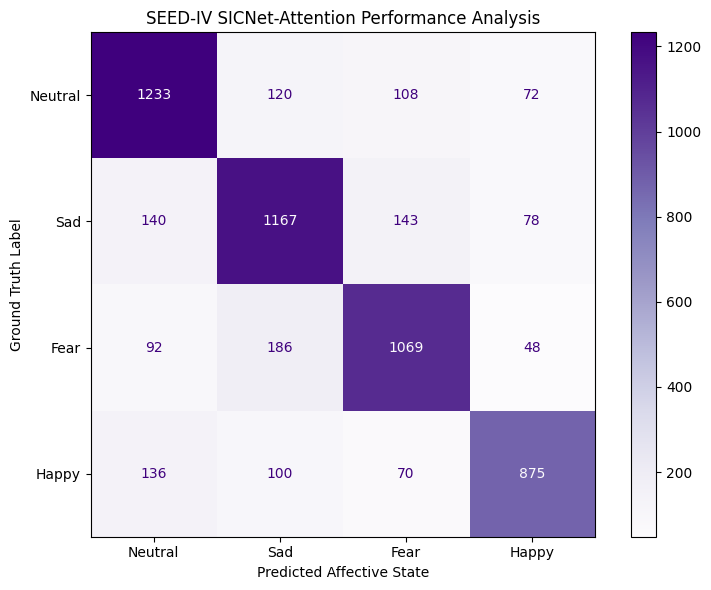

In [ ]:
# Cell 5: Confusion Matrix

def plot_clinical_performance(trues, preds):
    print("\nInitializing performance diagnostics...")
    class_names = ['Neutral', 'Sad', 'Fear', 'Happy']
    cm = confusion_matrix(trues, preds)

    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Purples', colorbar=True)

    plt.title('SEED-IV SICNet-Attention Performance Analysis', fontsize=12)
    plt.xlabel('Predicted Affective State')
    plt.ylabel('Ground Truth Label')
    plt.tight_layout()
    plt.show()

# Display Confusion Matrix
plot_clinical_performance(all_trues, all_preds)